## KNN Classification on Iris Dataset

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the Iris Dataset

In [13]:
iris = load_iris()
X = iris.data
y = iris.target

# Display the first few rows of the features and target
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# You can also convert to a DataFrame for better inspection
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]
display(iris_df.head())

Features (X) shape: (150, 4)
Target (y) shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. Split the Data into Training and Testing Sets

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)


### 3. Build and Train the KNN Classifier

In [15]:
# Initialize the KNN classifier with k=3 (a common choice for small datasets)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model using the training data
knn.fit(X_train, y_train)

print("KNN model trained successfully with n_neighbors=3.")

KNN model trained successfully with n_neighbors=3.


### 4. Make Predictions and Evaluate the Model

In [16]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9556


### 5. Visualize the Decision Boundary (Optional, for 2 features)

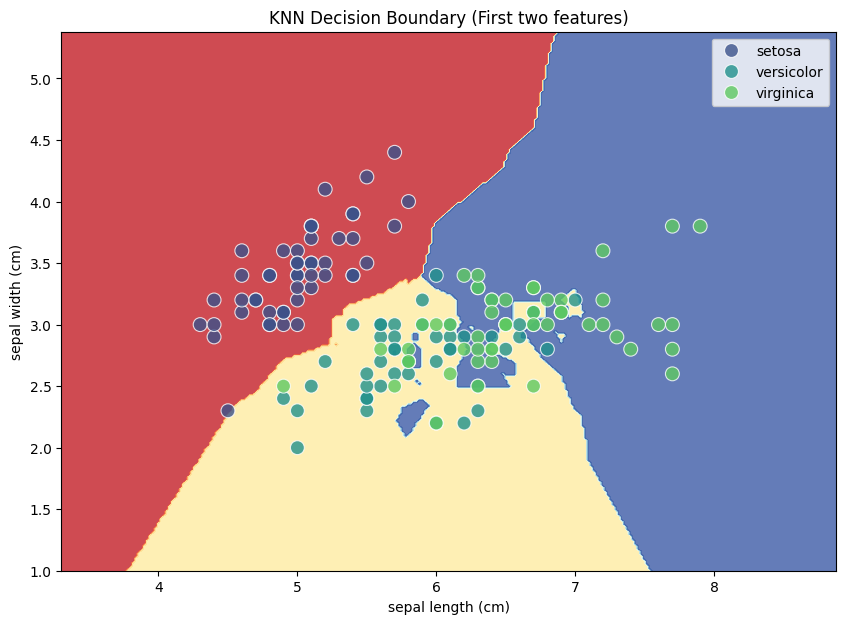

In [17]:
if X_train.shape[1] >= 2:
    # For visualization, let's just use the first two features
    X_2d = X[:, :2] # Using sepal length and sepal width
    y_2d = y

    # Split again for consistency with visualization
    X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.3, random_state=42, stratify=y_2d)

    knn_2d = KNeighborsClassifier(n_neighbors=3)
    knn_2d.fit(X_train_2d, y_train_2d)

    # Create a mesh to plot the decision boundary
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=iris.target_names[y_2d], palette='viridis', s=100, alpha=0.8)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title('KNN Decision Boundary (First two features)')
    plt.show()
else:
    print("Visualization of decision boundary requires at least two features.")